
# Numerical Integration

**Main Goal:** Perform a definite integral over a **known** interval and with a known integrand.

We'll investigate basic quadrature methods, error behavior, and simple adaptive ideas.
We will implement and test:
- Midpoint & Trapezoidal rules (single and composite)
- Simpson's rule (composite)
- Error vs. step size $h$ and order of accuracy
- A tiny adaptive Simpson integrator
- Quick checks against `scipy.integrate.quad`
- A simple Monte Carlo integral


In [1]:

import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import integrate



### Reminder from calculus (but that was so looong ago...)

##### A "Riemann sum" is **THE** fundamental concept in integral calculus

$$
\int_a^b f(x)\,dx \simeq \sum_{k=1}^N f(x_k^{\ast})\, dx
$$

where:
- $\Delta x = \frac{b-a}{N}$ is the width of each subinterval
- where $x_k^{\ast}$ is *some* point in the $k$-th subinterval


## Test functions and exact answers


$$
f(x) = \sin(x)
$$

$$
f(x) = e^{-x^2}
$$

$$
f(x) = 3x^2 + 2x + 1
$$

#### and because will need it:

$$
{\mathrm{erf(x)}} = \frac{2}{\sqrt{\pi}}\int_0^a e^{-x^2}\,dx
$$

In [4]:

def f_sin(x):
    return np.sin(x)

def f_exp2(x):
    return np.exp(-x**2)

def f_poly(x):
    return 3*x**2 + 2*x + 1

tests = [
    (f_sin, 0.0, np.pi, 2.0, r"$\int_0^{\pi} \sin x\,dx = 2$"),
    (f_poly, 0.0, 1.0, 3*(1/3) + 2*(1/2) + 1*(1) , r"$\int_0^1 (3x^2+2x+1)\,dx$"),
]

try:
    from math import erf, sqrt, pi
    exact_exp01 = 0.5*sqrt(pi)*erf(1.0)
except Exception:
    exact_exp01 = None

tests.append((f_exp2, 0.0, 1.0, exact_exp01, r"$\int_0^1 e^{-x^2}\,dx$"))

tests


[(<function __main__.f_sin(x)>,
  0.0,
  3.141592653589793,
  2.0,
  '$\\int_0^{\\pi} \\sin x\\,dx = 2$'),
 (<function __main__.f_poly(x)>,
  0.0,
  1.0,
  3.0,
  '$\\int_0^1 (3x^2+2x+1)\\,dx$'),
 (<function __main__.f_exp2(x)>,
  0.0,
  1.0,
  0.746824132812427,
  '$\\int_0^1 e^{-x^2}\\,dx$')]

![integration_simpson.png](integration_simpson.png)

![integration_trapezoid.png](integration_trapezoid.png)

![integration_midpoint.png](integration_midpoint.png)

![integration_left.png](integration_left.png)

![integration_right.png](integration_right.png)

![integration_methods_panels.png](integration_methods_panels.png)


## Single-interval rules


In [5]:

def midpoint_rule(f, a, b):
    return (b - a) * f((a + b) / 2.0)

def trapezoid_rule(f, a, b):
    return (b - a) * 0.5 * (f(a) + f(b))

def simpson_rule(f, a, b):
    m = 0.5 * (a + b)
    return (b - a) * (f(a) + 4.0*f(m) + f(b)) / 6.0


### Where does Simpson's Rule come from?

We want to want to approximate the integral $I = \int_a^b f(x)\,dx$

If we know $f(x)$ only at a few points, we can’t integrate it exactly.
But we can replace $f(x)$ by a simpler function — like a polynomial — that we **can** integrate exactly.

#### Step 1: Approximate $f(x)$ by a quadratic

Pick 3 points:
- $f(a)$ at $x = a$
- $f(m)$ at $x = m = \frac{a+b}{2}$
- $f(b)$ at $x = b$

Approximate $f(x)$ by a **quadratic polynomial** $P_2(x)$ 
that passes through these three points: $P_2(x) = Ax^2 + Bx + C$

The quadratic helps to follow $f(x)$ better than the straight line of the trapezoidal method.

#### Step 2: Use Lagrange Interpolation

Instead of solving for $A,B,C$ directly, we write 
$P_2(x)$ as a "Lagrange" polynomial:

$P_2(x)= f(a)L_0(x)+f(m)L_1(x)+f(b)L_2(x),$

where

 $$
 L_0(x) = \frac{(x-m)(x-b)}{(a-m)(a-b)}\\
 $$
 
 $$
 L_1(x) = \frac{(x-a)(x-b)}{(m-a)(m-b)}
 $$
 
 $$
 L_2(x) = \frac{(x-a)(x-m)}{(b-a)(b-m)}
 $$
 
 These polynomials satisfy $L_i(x_j) = \delta_{ij}$.
 

#### Step 3: Integrate the Quadratic Instead of $f(x)$

Now approximate the integral by:

$I = \int_a^bf(x)dx\simeq \int_a^bP_2(x)dx$

The integral is striaghtforward but tedious. The result is **Simpson's Rule**:

$\boxed{ \int_a^bf(x)dx\simeq \frac{b−a}{6}\left[f(a)+4f\left(\frac{a+b}{2}\right)+f(b)\right]}$



## Composite rules

Composite just means that you have an **even** number N of equally spaced intervals, not just one.


In [6]:

def composite_midpoint(f, a, b, N):
    h = (b - a) / N
    midpoints = a + (np.arange(N) + 0.5) * h
    return h * np.sum(f(midpoints))

def composite_trapezoid(f, a, b, N):
    h = (b - a) / N
    x = a + h * np.arange(N + 1)
    y = f(x)
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

def composite_simpson(f, a, b, N):
    if N % 2 == 1:
        raise ValueError("N must be even for composite Simpson's rule")
    h = (b - a) / N
    x = a + h * np.arange(N + 1)
    y = f(x)
    w = np.ones(N + 1)
    w[1:-1:2] = 4
    w[2:-1:2] = 2
    return h/3.0 * np.sum(w * y)


#### Left Riemann sum integrator

In [ ]:
def left_riemann(f, a, b, n):
    """
    Left Riemann sum for \int_a^b f(x) dx using n subintervals.
    Uses left endpoints x_k = a + k*dx for k = 0..n-1.
    """
    dx = (b - a) / n
    x_left = np.linspace(a, b, n + 1)[:-1]  # a, a+dx, ..., b-dx
    return np.sum(f(x_left)) * dx

# Example 1: \int_0^pi sin(x) dx  (exact = 2)
f1 = lambda x: np.sin(x)
# f1 = np.sin    #  looks super weird, missing argument? ok syntax when using *arrays*
a1, b1 = 0.0, np.pi


#### Try it !!! How well does it do?


## Convergence demo on $\int_0^{\pi}\sin(x)\,dx$
Expected errors: midpoint/trapezoid ~ O(h²); Simpson ~ O(h⁴).
Since h < 1, h^4 < h^2, and so we expect Simpson's rule to be more accurate than the midpoint/trapezoid integration scheme.


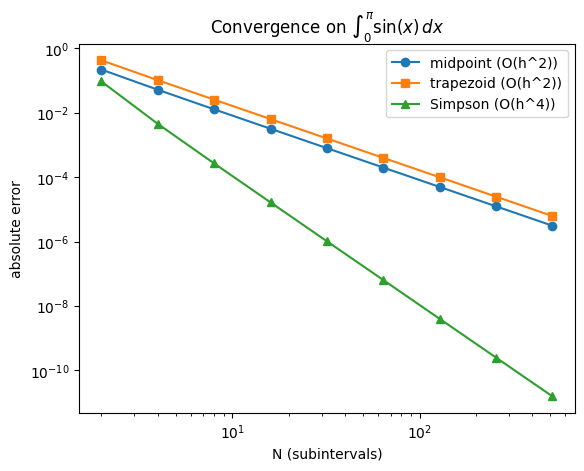

In [7]:

f, a, b, exact, _ = tests[0]  # sin on [0, pi]
Ns = np.array([2**k for k in range(1, 10)])

err_mid = []
err_trap = []
err_simp = []

for N in Ns:
    err_mid.append(abs(composite_midpoint(f, a, b, N) - exact))
    err_trap.append(abs(composite_trapezoid(f, a, b, N) - exact))
    N2 = N + (N % 2)  # make even
    err_simp.append(abs(composite_simpson(f, a, b, N2) - exact))

plt.figure()
plt.loglog(Ns, err_mid, marker='o', label="midpoint (O(h^2))")
plt.loglog(Ns, err_trap, marker='s', label="trapezoid (O(h^2))")
plt.loglog(Ns, err_simp, marker='^', label="Simpson (O(h^4))")
plt.xlabel("N (subintervals)")
plt.ylabel("absolute error")
plt.title("Convergence on $\int_0^{\pi}\sin(x)\,dx$")
plt.legend()
plt.show()


### Q: Is there already a python version of simpson's integrator? YES !!

In [ ]:
from scipy.integrate import simpson 
"""
see docs.scipy.org for documentation
"""

# \int_0^π sin(x) dx = 2            # exact value
x = np.linspace(0, np.pi, 101)      # 101 points → 100 subintervals (even)
y = np.sin(x)
I = simpson(y, x=x)                 # Note that x-vals and y-vals positions are swapped
print(I)                            # from their usual places


## Comparison with `scipy.integrate.quad`


In [33]:

from scipy import integrate
for f, a, b, exact, label in tests:
    val, err = integrate.quad(lambda x: float(f(x)), a, b)
    print(f"{label}: quad ≈ {val:.12g}  (est err ~ {err:.1e})  exact = {exact}")


$\int_0^{\pi} \sin x\,dx = 2$: quad ≈ 2  (est err ~ 2.2e-14)  exact = 2.0
$\int_0^1 (3x^2+2x+1)\,dx$: quad ≈ 3  (est err ~ 3.3e-14)  exact = 3.0
$\int_0^1 e^{-x^2}\,dx$: quad ≈ 0.746824132812  (est err ~ 8.3e-15)  exact = 0.746824132812427


In [34]:
f = lambda x: np.exp(-x**2)
I, err = integrate.quad(f, 0, np.inf)

Note: $\int_0^{\infty} e^{-x^2}= \frac{\sqrt{\pi}}{2}$

In [39]:
print("I =",I, '   ', "err =", err)

I = 0.8862269254527579     err = 7.101318390472462e-09


**Take away:** quad is good for error estimates and infinite limits. Simpson is good for tabulated data.


## Monte Carlo integration (very simple)


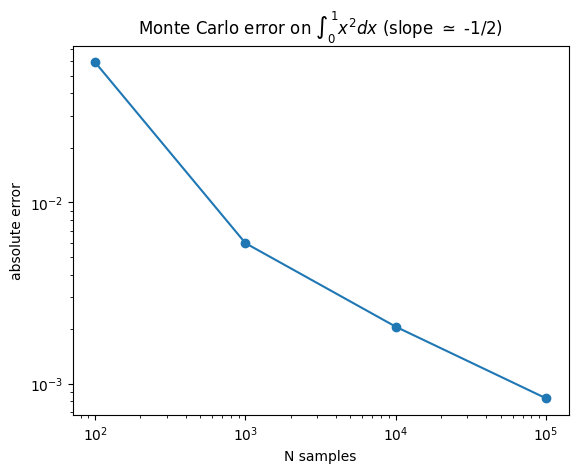

[(np.int64(100), np.float64(0.39249194193371784)),
 (np.int64(1000), np.float64(0.33929725680866524)),
 (np.int64(10000), np.float64(0.33126761324415466)),
 (np.int64(100000), np.float64(0.3325008761638391))]

In [43]:

rng = np.random.default_rng(0)

def mc_integrate_01(f, N=10_000):
    x = rng.random(N)
    return np.mean(f(x))

Ns = np.array([10**k for k in range(2,6)])
mc_vals = []
for N in Ns:
    mc_vals.append(mc_integrate_01(lambda x: x**2, N))

exact = 1/3
plt.figure()
plt.loglog(Ns, np.abs(np.array(mc_vals) - exact), marker='o')
plt.xlabel("N samples")
plt.ylabel("absolute error")
plt.title("Monte Carlo error on $\int_0^1 x^2 dx$ (slope $\simeq$ -1/2)")
plt.show()

list(zip(Ns, mc_vals))


##### Footnote about zip():

In [41]:
Ns = [100, 1000, 10000]
mc_vals = [3.14, 3.142, 3.1416]
list(zip(Ns, mc_vals))

[(100, 3.14), (1000, 3.142), (10000, 3.1416)]

---
---
##  Exercises

1) Implement **left** and **right** Riemann sums and compare to midpoint/trapezoid on the test problems.  
2) Integrate $f(x)= \sqrt(x)\cos x$ on $[0,10]$ using multiple techniques. Compare results.  
3) For $f(x)=e^{-x^2}$ on $[0,1]$, make a **log–log plot** of error vs. $N$ for trapezoid and Simpson; estimate slopes.  
4) **Challenging** Try an **improper integral**: \(\int_0^1 x^{-1/2}\,dx\). Use a change of variables (e.g., \(x=t^2\)) and compare methods.

---
---


### 9 Oct '25 Exercise. MC Integration

1) Verify that `rng.random()` used above works as advertized. Do this by plotting random x and random y values and observe the pattern.  
Make an x-array and a y-array and then use plt.scatter(x,y) to produce a "scatter" plot of the points $(x,y)$.   
What do you see if the number of random points N = 100, 1000, 10_000? Is this what you expect?    
You may want to make the plot area larger than the defaut value using the `figsize` keyword in `plt.figure()`.

3) Using the Monte Carlo (MC) technique, numerically integrate $\int_5^{5 + 2\pi}(10+\cos(2x))e^{-(x-5)/{2\pi}}$.   
Note that you will need to modify rng.random slightly.  How would you randomly generate numbers between $[0,2\pi]$, between $[-1,1]$?     
You may want to see the integrand's shape by plotting it over the interval $[5, 5+2\pi]$.   
Based on the shape of the integrand, does your numerical answer seem reasonable?